In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.samplers import TPESampler

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Работа с данными

In [2]:
data = fetch_california_housing(as_frame=True)
df: pd.DataFrame = data.frame
X: pd.DataFrame = data.data
y: pd.DataFrame = data.target

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


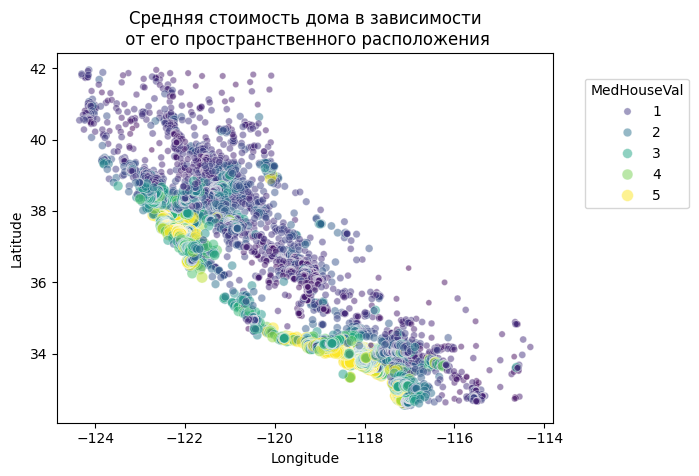

In [5]:
sns.scatterplot(data=df, x="Longitude", y="Latitude", size="MedHouseVal", hue="MedHouseVal", palette="viridis", alpha=0.5)
plt.legend(title="MedHouseVal", bbox_to_anchor=(1.05, 0.95), loc="upper left")
_ = plt.title("Средняя стоимость дома в зависимости\n от его пространственного расположения")

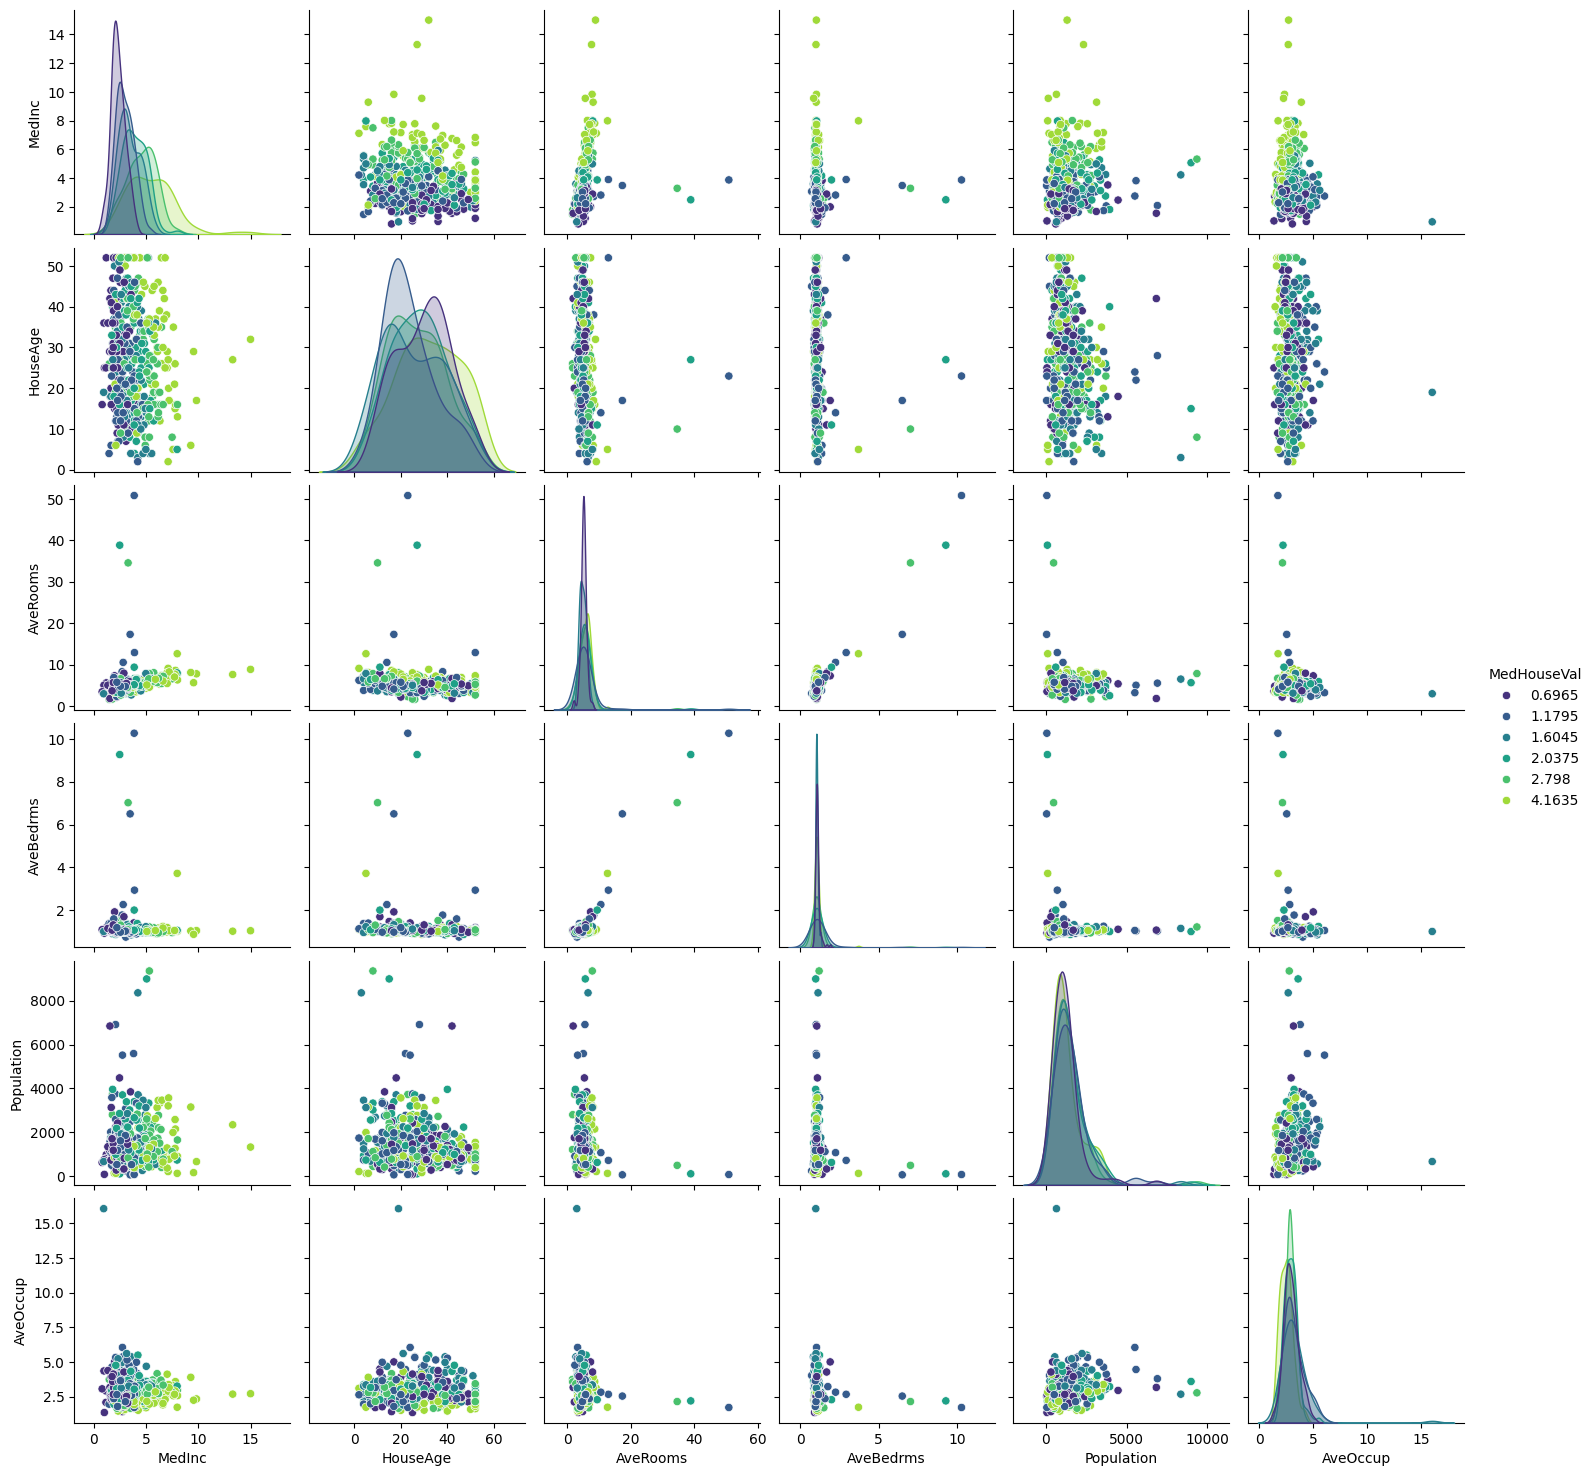

In [6]:
rng = np.random.RandomState(0)
indices = rng.choice(np.arange(df.shape[0]), size=500, replace=False)

columns_drop = ["Longitude", "Latitude"]
subset = df.iloc[indices].drop(columns=columns_drop)
subset["MedHouseVal"] = pd.qcut(subset["MedHouseVal"], 6, retbins=False)
subset["MedHouseVal"] = subset["MedHouseVal"].apply(lambda x: x.mid)
_ = sns.pairplot(data=subset, hue="MedHouseVal", palette="viridis")

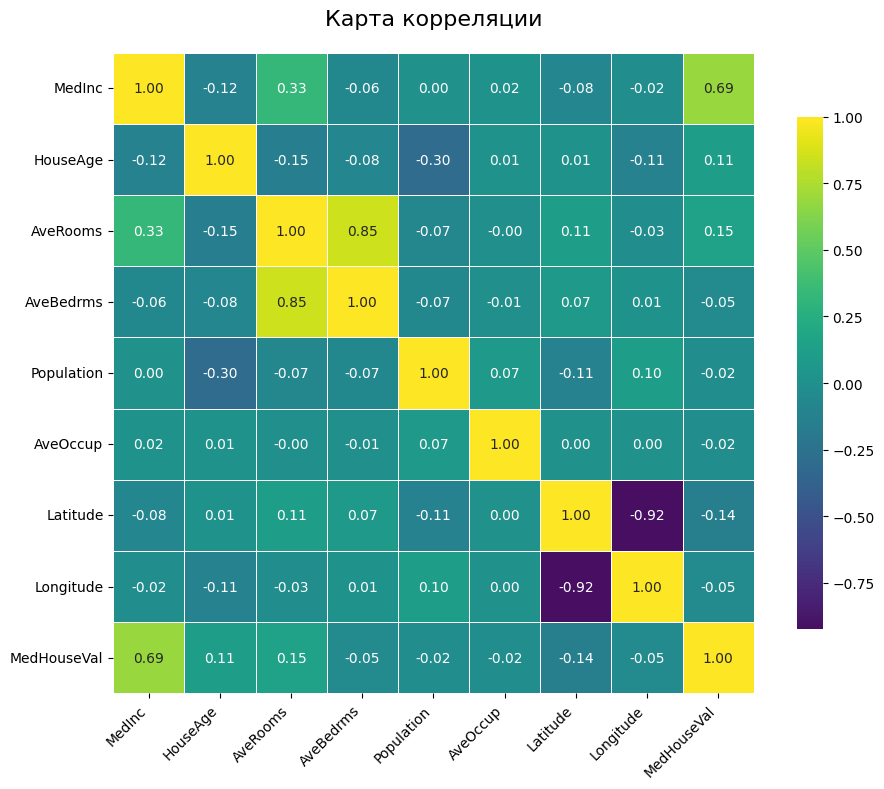

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='viridis', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Карта корреляции", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))

In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X.head()

,0,1,2,3,4,5,6,7
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


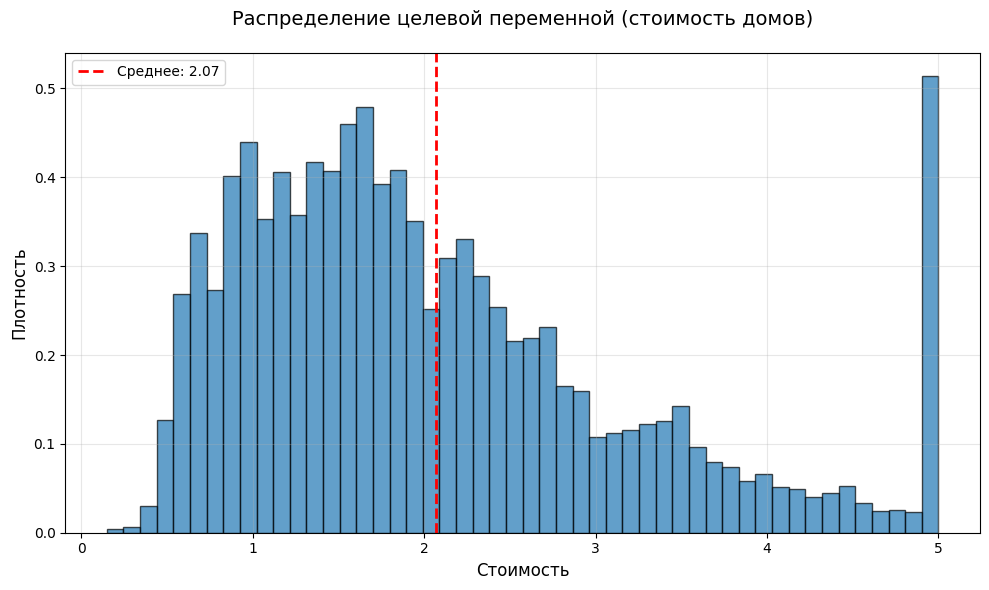

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(y, bins=50, alpha=0.7, edgecolor='black', density=True)
plt.title('Распределение целевой переменной (стоимость домов)', fontsize=14, pad=20)
plt.xlabel('Стоимость', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {y.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Для этого набора данных я выбрал соотношение 80/20. Это стандартное разделение, которое обеспечивает достаточное количество данных для обучения (80%) при сохранении репрезентативной тестовой выборки (20%) для валидации модели.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (15480, 8)
Размер тестовой выборки: (5160, 8)


# Работа с моделью

Для данной задачи я выбрал Gradient Boosting по следующим причинам:

- Высокая точность
- Нелинейность
- Робастность

Почему не другие модели:
- Linear Models: Не улавливают сложные нелинейности цен
- Single Decision Tree: Сильно переобучается, низкая точность  
- Random Forest: Хуже обобщает из-за бутстрэпа и независимости деревьев
- Neural Networks: Перебор для данного объема данных, требует больше настройки

В качестве метрик качества буду использовать:
- $\text{MAE}$ (Mean Absolute Error) - интерпретируемая метрика в единицах целевой переменной
- $\text{RMSE}$ (Root Mean Square Error) - более чувствительна к большим ошибкам
- $\text{R}^2$ (коэффициент детерминации) - показывает долю объясненной дисперсии

In [13]:
def evaluate_model(y_true, y_pred, test_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    if test_name:
        print(f"--- {test_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print()
    
    return mae, rmse, r2

In [ ]:
def gen_objective(estimator_class, grid, X_train, y_train, X_test, y_test, criterion, /, cv=False, **kwargs):
    def objective(trial):
        params = {}
        for param_name, param_config in grid.items():
            if param_config['type'] == 'categorical':
                params[param_name] = trial.suggest_categorical(
                    param_name, param_config['values']
                )
            elif param_config['type'] == 'int':
                params[param_name] = trial.suggest_int(
                    param_name, 
                    param_config['low'], 
                    param_config['high']
                )
            elif param_config['type'] == 'float':
                if param_config.get('log', False):
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high'], 
                        log=True
                    )
                else:
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high']
                    )
        
        model = estimator_class(**params, **kwargs)
        
        if cv:
            scores = []
            for train_idx, val_idx in KFold(n_splits=cv, shuffle=True, random_state=42).split(X_train):
                X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
                model.fit(X_fold_train, y_fold_train)
                y_pred = model.predict(X_fold_val)
                score = criterion(y_fold_val, y_pred)
                scores.append(score)
            
            result = np.mean(scores)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            result = criterion(y_test, y_pred)
        
        return result
    
    return objective

In [15]:
gb_grid = {
    'n_estimators': {'type': 'int', 'low': 100, 'high': 300},
    'max_depth': {'type': 'int', 'low': 3, 'high': 6},
    'learning_rate': {'type': 'float', 'low': 0.05, 'high': 0.15},
    'min_samples_split': {'type': 'int', 'low': 50, 'high': 100},
    'min_samples_leaf': {'type': 'int', 'low': 20, 'high': 50},
    'subsample': {'type': 'float', 'low': 0.7, 'high': 0.9},
    'max_features': {'type': 'categorical', 'values': ['sqrt']}
}

rmse = lambda true, pred: np.sqrt(mean_squared_error(true, pred))

objective = gen_objective(
    GradientBoostingRegressor, 
    gb_grid, 
    X_train, y_train, 
    X_test, y_test, 
    rmse, 
    random_state=42
)

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, n_jobs=-1, show_progress_bar=True)

print("Лучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print(f"Лучшее значение RMSE: {study.best_value:.4f}")

[I 2025-09-26 16:28:28,355] A new study created in memory with name: no-name-672c4dd8-6037-42e5-85d6-03eb2659c411


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-09-26 16:28:30,816] Trial 7 finished with value: 0.5702535990304591 and parameters: {'n_estimators': 132, 'max_depth': 3, 'learning_rate': 0.06356624172574837, 'min_samples_split': 99, 'min_samples_leaf': 50, 'subsample': 0.8485824015247855, 'max_features': 'sqrt'}. Best is trial 7 with value: 0.5702535990304591.
[I 2025-09-26 16:28:32,010] Trial 0 finished with value: 0.5496839900507938 and parameters: {'n_estimators': 207, 'max_depth': 3, 'learning_rate': 0.05673940570842252, 'min_samples_split': 94, 'min_samples_leaf': 36, 'subsample': 0.7082719851191354, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5496839900507938.
[I 2025-09-26 16:28:32,894] Trial 1 finished with value: 0.47428187807396455 and parameters: {'n_estimators': 130, 'max_depth': 6, 'learning_rate': 0.14399690728303277, 'min_samples_split': 92, 'min_samples_leaf': 38, 'subsample': 0.8217223799691756, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.47428187807396455.
[I 2025-09-26 16:28:34,111] T

In [16]:
best_params = study.best_params
best_model = GradientBoostingRegressor(**best_params)
best_model.fit(X_train, y_train)

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("Качество на обучающей выборке:")
train_metrics = evaluate_model(y_train, y_pred_train, "Обучающая выборка")

print("Качество на тестовой выборке:")
test_metrics = evaluate_model(y_test, y_pred_test, "Тестовая выборка")

Качество на обучающей выборке:
--- Обучающая выборка ---
MAE: 0.2432
RMSE: 0.3509
R²: 0.9077

Качество на тестовой выборке:
--- Тестовая выборка ---
MAE: 0.3117
RMSE: 0.4664
R²: 0.8356



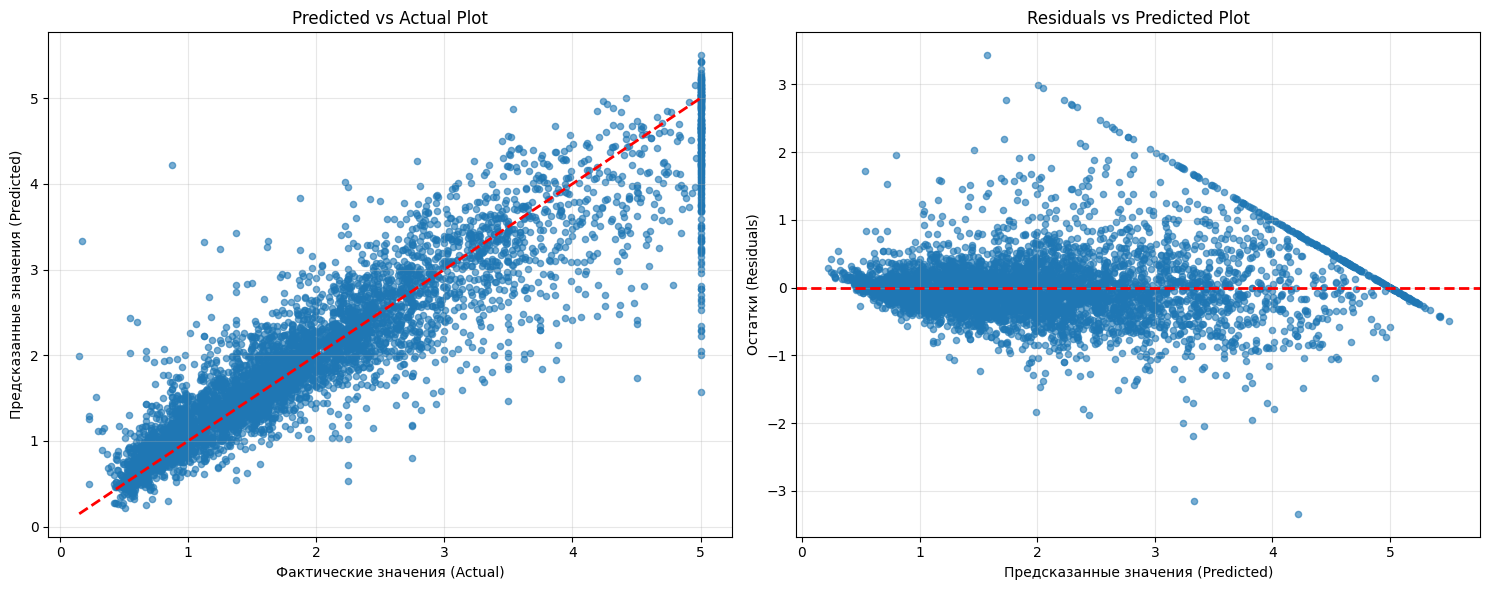

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred_test, alpha=0.6, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения (Actual)')
axes[0].set_ylabel('Предсказанные значения (Predicted)')
axes[0].set_title('Predicted vs Actual Plot')
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Предсказанные значения (Predicted)')
axes[1].set_ylabel('Остатки (Residuals)')
axes[1].set_title('Residuals vs Predicted Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()